In [278]:
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [279]:
df = pd.read_csv("/Users/raghav/Documents/Pokemon Data.csv")

In [280]:
df.head()

,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


In [281]:
print(df.columns.tolist())

['abilities', 'against_bug', 'against_dark', 'against_dragon', 'against_electric', 'against_fairy', 'against_fight', 'against_fire', 'against_flying', 'against_ghost', 'against_grass', 'against_ground', 'against_ice', 'against_normal', 'against_poison', 'against_psychic', 'against_rock', 'against_steel', 'against_water', 'attack', 'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate', 'classfication', 'defense', 'experience_growth', 'height_m', 'hp', 'japanese_name', 'name', 'percentage_male', 'pokedex_number', 'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg', 'generation', 'is_legendary']


In [282]:
names = df['name'].str.lower().str.strip()

In [283]:
names.head(10)

0     bulbasaur
1       ivysaur
2      venusaur
3    charmander
4    charmeleon
5     charizard
6      squirtle
7     wartortle
8     blastoise
9      caterpie
Name: name, dtype: object

In [284]:
len(names)

801

In [285]:
names = df['name'].str.lower().str.strip().tolist()
names = [name for name in names if name.isalpha()]
print(names[:5])
print(f"Total: {len(names)}")

['bulbasaur', 'ivysaur', 'venusaur', 'charmander', 'charmeleon']
Total: 785


In [286]:
chars = sorted(list(set(''.join(names))))
chars


['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 'é']

In [287]:
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [288]:
def build_dataset(names):
    block_size = 3
    X,Y = [],[]
    for name in names:
        context = [0] * block_size
        for ch in name + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape)
    print(Y.shape)
    return X,Y
            


import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr,Ytr = build_dataset(names[:n1])
Xdev,Ydev = build_dataset(names[n1:n2])
Xte,Yte = build_dataset(names[n2:])
        

torch.Size([5317, 3])
torch.Size([5317])
torch.Size([663, 3])
torch.Size([663])
torch.Size([652, 3])
torch.Size([652])


In [289]:
vocab_size = len(stoi)
vocab_size

28

Experiment - 0

In [290]:
C = torch.randn(vocab_size,2)
W1 = torch.randn(6,100)
b1 = torch.rand(100)
W2 = torch.randn(100,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [291]:
sum(p.nelement() for p in parameters)

3584

In [292]:
for p in parameters:
    p.requires_grad = True

In [293]:
lossi = []
stepi = []

In [294]:
for i in range(30000):
    #forward pass
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(emb.shape[0],-1)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 10000 == 0:
        print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    stepi.append(i)

18.628032684326172
2.3941810131073
3.1323955059051514


Experiment 0 (baseline): emb_dim=2, hidden=100, block_size=3, steps=30000, lr=0.1 → loss=2.29

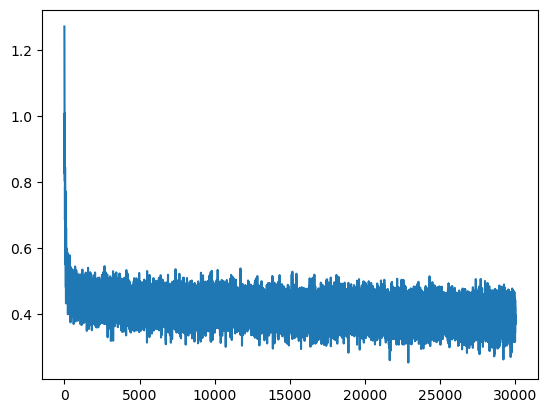

In [295]:
plt.plot(lossi)

Experiment 1

In [296]:
C = torch.randn(vocab_size,10)
W1 = torch.randn(30,100)
b1 = torch.rand(100)
W2 = torch.randn(100,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [297]:
sum(p.nelement() for p in parameters)

6208

In [298]:
for p in parameters:
    p.requires_grad = True

In [299]:
lossi = []
stepi = []

In [300]:
for i in range(30000):
    #forward pass
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(emb.shape[0],-1)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 10000 == 0:
        print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    stepi.append(i)

20.280683517456055
1.9094902276992798
1.9569551944732666


Experiment 1: emb_dim=10, hidden=100, block_size=3, steps=30000, lr=0.1 → loss=2.10

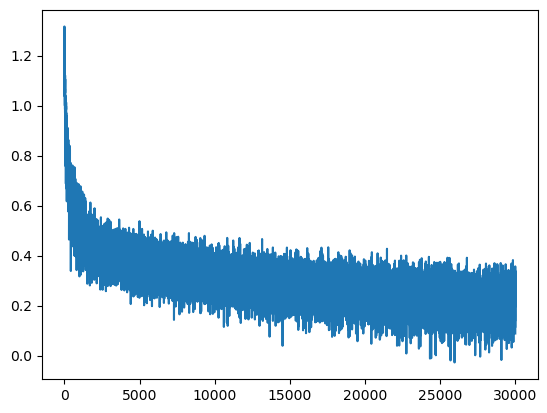

In [301]:
plt.plot(lossi)

Experiment 2

In [302]:
C = torch.randn(vocab_size,10)
W1 = torch.randn(30,300)
b1 = torch.rand(300)
W2 = torch.randn(300,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [303]:
sum(p.nelement() for p in parameters)

18008

In [304]:
for p in parameters:
    p.requires_grad = True

In [305]:
lossi = []
stepi = []

In [306]:
for i in range(30000):
    #forward pass
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(emb.shape[0],-1)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 10000 == 0:
        print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    stepi.append(i)

34.87310028076172
1.4412165880203247
0.7235448956489563


Experiment 2: emb_dim=10, hidden=300, block_size=3, steps=30000, lr=0.1 → loss=1.73

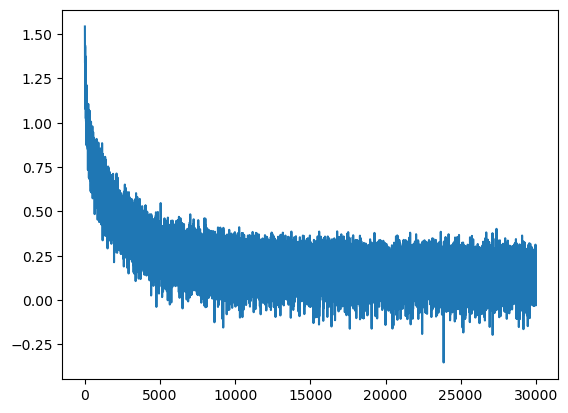

In [307]:
plt.plot(lossi)

Experiment 3

In [308]:
def build_dataset(names):
    block_size = 5
    X,Y = [],[]
    for name in names:
        context = [0] * block_size
        for ch in name + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape)
    print(Y.shape)
    return X,Y
            


import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

Xtr,Ytr = build_dataset(names[:n1])
Xdev,Ydev = build_dataset(names[n1:n2])
Xte,Yte = build_dataset(names[n2:])
        

torch.Size([5311, 5])
torch.Size([5311])
torch.Size([657, 5])
torch.Size([657])
torch.Size([664, 5])
torch.Size([664])


In [309]:
C = torch.randn(vocab_size,10)
W1 = torch.randn(50,300)
b1 = torch.rand(300)
W2 = torch.randn(300,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [310]:
sum(p.nelement() for p in parameters)

24008

In [311]:
for p in parameters:
    p.requires_grad = True

In [312]:
lossi = []
stepi = []

In [313]:
for i in range(30000):
    #forward pass
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(emb.shape[0],-1)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 10000 == 0:
        print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    stepi.append(i)

32.0273551940918
1.040661096572876
1.254317045211792


Experiment 3: emb_dim=10, hidden=300, block_size=5, steps=30000, lr=0.1 → loss=1.16

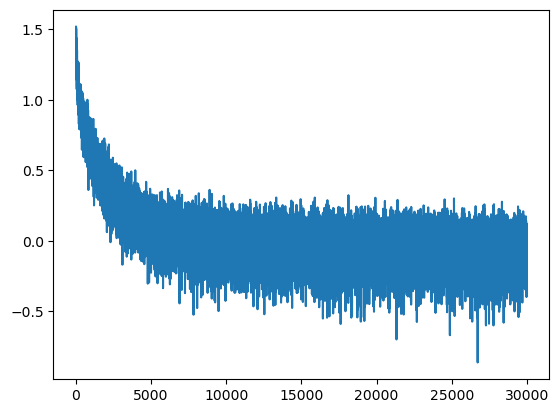

In [314]:
plt.plot(lossi)

Experiment 4

In [315]:
C = torch.randn(vocab_size,10)
W1 = torch.randn(50,300)
b1 = torch.rand(300)
W2 = torch.randn(300,vocab_size)
b2 = torch.randn(vocab_size)

parameters = [C,W1,b1,W2,b2]

In [316]:
sum(p.nelement() for p in parameters)

24008

In [317]:
for p in parameters:
    p.requires_grad = True

In [318]:
lossi = []
stepi = []

In [319]:
for i in range(30000):
    #forward pass
    ix = torch.randint(0,Xtr.shape[0],(32,))
    emb = C[Xtr[ix]]
    emb = emb.view(emb.shape[0],-1)
    h = torch.tanh(emb @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])

    if i % 10000 == 0:
        print(loss.item())
    
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad

    lossi.append(loss.log10().item())
    stepi.append(i)

32.5017204284668
3.5718319416046143
1.8864082098007202


Exp 4:            emb_dim=10, hidden=300, block_size=5, lr=0.01 → 1.51

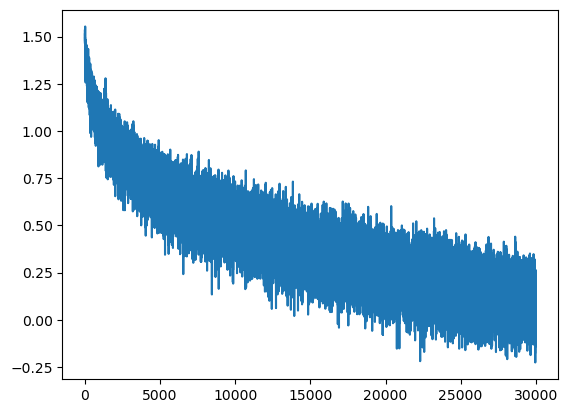

In [320]:
plt.plot(lossi)

| Experiment | emb_dim | hidden | block_size | lr | loss |
|---|---|---|---|---|---|
| Baseline | 2 | 100 | 3 | 0.1 | 2.29 |
| Exp 1 | 10 | 100 | 3 | 0.1 | 2.10 |
| Exp 2 | 10 | 300 | 3 | 0.1 | 1.73 |
| Exp 3 | 10 | 300 | 5 | 0.1 | 1.16 |
| Exp 4 | 10 | 300 | 5 | 0.01 | 1.51 |

In [328]:
block_size = 5
for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim = 1)
        ix = torch.multinomial(probs,num_samples = 1,generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    # print(''.join(itos[i]) for i in out))
    print(''.join(itos[i] for i in out))
 

toumasee.
seaccle.
galvantuyr.
abexek.
tyndyoagr.
exeggcute.
starst.
drifb.
uzeli.
kakuna.
wobba.
turtiulap.
electnj.
cuykodshkashint.
silvat.
wingull.
liepare.
poliwag.
carsaring.
swaly.


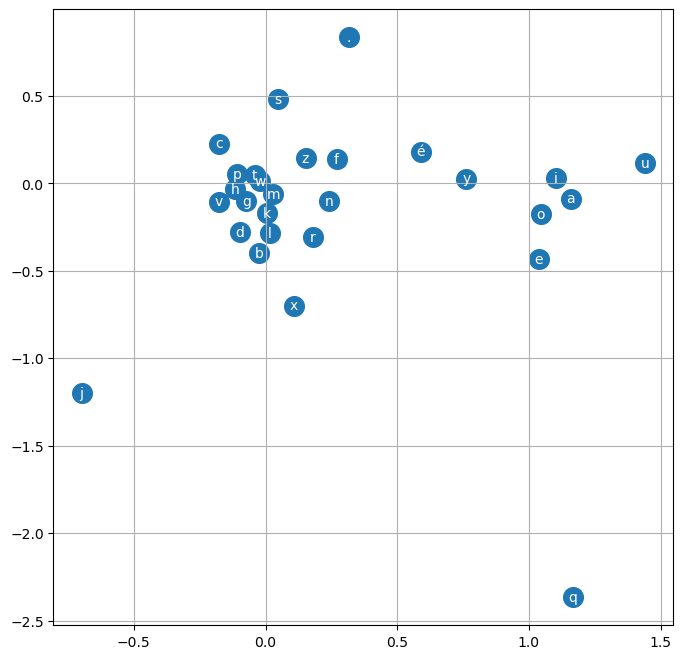

In [325]:
C_vis = torch.randn(vocab_size, 2)
W1_vis = torch.randn(10, 100)
b1_vis = torch.randn(100)
W2_vis = torch.randn(100, vocab_size)
b2_vis = torch.randn(vocab_size)
params_vis = [C_vis, W1_vis, b1_vis, W2_vis, b2_vis]

for p in params_vis:
    p.requires_grad = True

lossi_vis = []
for i in range(30000):
    ix = torch.randint(0, Xtr.shape[0], (32,))
    emb = C_vis[Xtr[ix]]
    emb = emb.view(emb.shape[0], -1)
    h = torch.tanh(emb @ W1_vis + b1_vis)
    logits = h @ W2_vis + b2_vis
    loss = F.cross_entropy(logits, Ytr[ix])
    for p in params_vis:
        p.grad = None
    loss.backward()
    for p in params_vis:
        p.data += -0.1 * p.grad
    lossi_vis.append(loss.log10().item())

# Plot embeddings
plt.figure(figsize=(8,8))
plt.scatter(C_vis[:,0].data, C_vis[:,1].data, s=200)
for i in range(vocab_size):
    plt.text(C_vis[i,0].item(), C_vis[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')
plt.show()